In [2]:
import torch

In [5]:
torch.zeros(3,3)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [12]:
f = lambda x,y : x+y

In [14]:
f(1,2)

3

In [29]:
import torch
import numpy as np

# 创建一个 torch.Tensor（假设在 GPU 上）
tensor = torch.tensor([1.0, 2.0, 3.0], device='cuda')

# 将 GPU tensor 移动到 CPU
tensor_cpu = tensor.to('cpu')

# 将 tensor 转换为 numpy 数组
numpy_array = tensor_cpu.numpy()

# 使用 numpy 函数进行处理
result = np.sqrt(numpy_array)

print("Torch Tensor:", tensor)
print("Numpy Array:", numpy_array)
print("Result after applying numpy function:", result)

AssertionError: Torch not compiled with CUDA enabled

In [77]:
import torch

# 生成示例数据
data_dict = {
    'inputs': torch.randn(100, 3, 32, 32),  # 例如100个32x32的RGB图像
    'labels': torch.randint(0, 10, (100,)),  # 100个随机标签，范围在0到9之间
    'metadata': torch.arange(100)  # 额外的元数据，例如索引
}

# 保存数据到文件
torch.save(data_dict, 'data_dict.pt')

In [89]:
from torch.utils.data import Dataset

class DictDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data[list(self.data.keys())[0]])
    
    def __getitem__(self, idx):
        return {
            _param: self.data[_param][idx] for _param in self.data.keys()
        }


In [93]:
from torch.utils.data import DataLoader

# 创建自定义 Dataset
dataset = DictDataset('data_dict.pt')

# 创建 DataLoader
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

i = 0
# 迭代 DataLoader
for batch in dataloader:
    i += 1
    inputs = batch['inputs']
    labels = batch['labels']
    metadata = batch['metadata']
    print(f'Begin the {i}th iter.')
    print("Batch inputs:", inputs.shape)
    print("Batch labels:", labels)
    print("Batch metadata:", metadata)

Begin the 1th iter.
Batch inputs: torch.Size([100, 3, 32, 32])
Batch labels: tensor([5, 1, 8, 4, 0, 5, 3, 4, 0, 7, 8, 2, 2, 7, 6, 1, 5, 1, 1, 5, 5, 9, 1, 4,
        7, 7, 6, 9, 2, 0, 6, 4, 5, 9, 9, 6, 1, 7, 2, 8, 8, 4, 7, 0, 8, 8, 9, 4,
        7, 6, 5, 3, 5, 3, 3, 3, 5, 0, 5, 2, 4, 1, 3, 0, 8, 6, 9, 1, 4, 7, 1, 7,
        8, 1, 3, 6, 6, 8, 1, 3, 9, 0, 6, 5, 9, 0, 8, 8, 4, 8, 3, 1, 0, 1, 7, 8,
        3, 7, 9, 6])
Batch metadata: tensor([36, 74, 52, 48, 24, 66,  7, 49, 89, 19, 64, 70, 71, 18, 35, 63, 47, 55,
        61, 88, 54, 83, 99,  5, 39, 58,  8, 57, 31, 41, 75, 32,  9, 95,  0, 14,
        40, 11, 68, 78, 97, 15, 67, 56, 77, 91, 93, 20, 33, 42,  4, 51, 82, 26,
        27, 23, 59, 98, 60, 50, 86, 92, 13, 16, 29, 25, 76, 65, 17, 46,  6, 72,
        37, 34, 21, 38, 90, 73, 85, 79, 81,  2, 96, 30, 22,  1, 53, 62, 84, 43,
        28, 12,  3, 10, 45, 87, 44, 69, 80, 94])


In [76]:
batch

{'inputs': tensor([[[[-0.8878, -0.5280,  0.1571,  ..., -0.2808, -0.0331,  0.0818],
           [ 0.5474,  0.5612, -1.4993,  ..., -0.7754,  0.2853, -0.2096],
           [-0.4529,  0.2906, -0.4952,  ...,  0.4406, -3.1002,  0.8245],
           ...,
           [-0.2646,  1.0569, -0.3854,  ...,  0.6995,  0.3297, -0.0245],
           [ 0.4720, -0.9401,  0.7449,  ...,  0.3366,  0.2248,  0.7251],
           [-1.1675,  0.8933,  0.7283,  ...,  2.7504, -0.6177,  0.4153]],
 
          [[ 0.9172, -0.9144,  1.7102,  ...,  2.4420, -1.7069,  0.1822],
           [-1.6621,  0.6032,  0.8857,  ...,  0.8098,  1.4453,  0.9608],
           [-1.0998,  1.5644,  0.7560,  ..., -0.1020, -0.0682, -1.9430],
           ...,
           [-1.0336,  0.3492, -2.0704,  ..., -0.3594, -1.7510,  1.5424],
           [ 1.1361, -0.0157,  1.0471,  ..., -0.6884, -1.7066,  0.6882],
           [ 0.4718, -2.3903, -0.7172,  ..., -0.2150,  0.9472, -0.2996]],
 
          [[ 0.0534, -1.0858,  1.1246,  ..., -1.4638, -1.3288,  0.5966],
   

In [94]:
x = torch.randn(3,3)

In [95]:
a, b = x[:,0:1], x[:,1:1]

In [96]:
a

tensor([[ 0.1427],
        [-0.7871],
        [-0.1565]])

In [99]:
torch.cat([a,b],-1)

tensor([[ 0.1427],
        [-0.7871],
        [-0.1565]])

In [103]:
x = torch.ones(3)

In [122]:
import torch

# 示例数据：两个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
y = torch.tensor([[7, 8, 9], [10, 11, 12]])

# 创建二维网格
x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')

print("x_grid:\n", x_grid)
print("y_grid:\n", y_grid)

RuntimeError: torch.meshgrid: Expected 0D or 1D tensor in the tensor list but got:  1  2  3
 4  5  6
[ torch.LongTensor{2,3} ]

In [121]:
torch.randn(3).T - torch.randn(4,3)

tensor([[ 1.5044,  1.5890,  0.4441],
        [-0.1163,  1.8807, -1.8963],
        [ 0.9823,  0.4542, -2.1945],
        [-0.8877,  2.3493,  0.1210]])

In [2]:
int(10/1)

10

In [130]:
x.unsqueeze(0)

tensor([[[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]]])

In [131]:
x.repeat(2,1,1)

tensor([[[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]],

        [[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]]])

In [135]:
x.repeat_interleave(2,0)

tensor([[-0.5687,  0.2368,  0.9420],
        [-0.5687,  0.2368,  0.9420],
        [ 0.1780,  0.1297, -0.5389],
        [ 0.1780,  0.1297, -0.5389],
        [ 0.2828,  2.1941,  1.3216],
        [ 0.2828,  2.1941,  1.3216]])

In [1]:

import torch

In [24]:
x = torch.load("/home/ycui/Documents/deepOnet_bermudan/data/free_test_num_ex_2_max_4.4_var_scale_2_length_scale_100/test/test_0.pt")

In [34]:
x["q"].max()

tensor(0.0498, device='cuda:1')

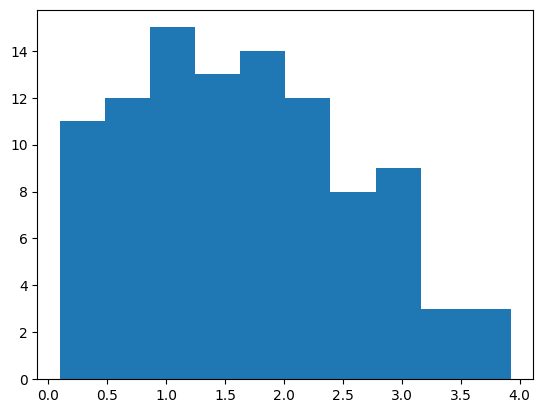

In [23]:
import matplotlib.pyplot as plt

plt.hist(x["solution"].flatten().cpu())
plt.show()

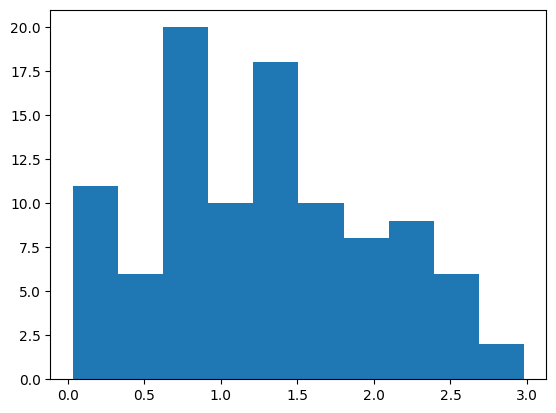

In [25]:
import matplotlib.pyplot as plt

plt.hist(x["solution"].flatten().cpu())
plt.show()

In [35]:
for _p in x:
    print(f"The {_p} is {x[_p][1]}")

The payoff is tensor([10.1041, 10.1025, 10.1007, 10.0988, 10.0967, 10.0944, 10.0919, 10.0892,
        10.0863, 10.0831, 10.0796, 10.0758, 10.0717, 10.0672, 10.0623, 10.0570,
        10.0512, 10.0449, 10.0381, 10.0306, 10.0225, 10.0136, 10.0040,  9.9935,
         9.9821,  9.9696,  9.9561,  9.9414,  9.9254,  9.9079,  9.8889,  9.8682,
         9.8457,  9.8212,  9.7945,  9.7655,  9.7339,  9.6995,  9.6621,  9.6213,
         9.5769,  9.5286,  9.4760,  9.4188,  9.3565,  9.2887,  9.2148,  9.1345,
         9.0470,  8.9517,  8.8481,  8.7352,  8.6124,  8.4787,  8.3331,  8.1747,
         8.0022,  7.8145,  7.6101,  7.3876,  7.1454,  6.8818,  6.5949,  6.2825,
         5.9424,  5.5723,  5.1694,  4.7308,  4.2533,  3.7336,  3.1679,  2.5520,
         1.8817,  1.1519,  0.3576,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, 

In [30]:
num_ex = 2
J = int((int(1000/num_ex) + 1) * num_ex)

In [31]:
J

1002

In [32]:
dJ = int(J/num_ex)

In [33]:
dJ

501